### Project 

In [1]:
import pandas as pd

df = pd.read_csv("data/Credit Risk Benchmark Dataset.csv")
df.head()


,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
0,0.006999,38.0,0.0,0.302150,5440.0,4.0,0.0,1.0,0.0,3.0,0
1,0.704592,63.0,0.0,0.471441,8000.0,9.0,0.0,1.0,0.0,0.0,0
2,0.063113,57.0,0.0,0.068586,5000.0,17.0,0.0,0.0,0.0,0.0,0
3,0.368397,68.0,0.0,0.296273,6250.0,16.0,0.0,2.0,0.0,0.0,0
4,1.000000,34.0,1.0,0.000000,3500.0,0.0,0.0,0.0,0.0,1.0,0


In [2]:
df.shape
df.info()
df.isna().sum()
df.describe(include="all")


<class 'pandas.DataFrame'>
RangeIndex: 16714 entries, 0 to 16713
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rev_util     16714 non-null  float64
 1   age          16714 non-null  float64
 2   late_30_59   16714 non-null  float64
 3   debt_ratio   16714 non-null  float64
 4   monthly_inc  16714 non-null  float64
 5   open_credit  16714 non-null  float64
 6   late_90      16714 non-null  float64
 7   real_estate  16714 non-null  float64
 8   late_60_89   16714 non-null  float64
 9   dependents   16714 non-null  float64
 10  dlq_2yrs     16714 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.4 MB


,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
count,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000,16714.000000
mean,4.799862,48.798672,1.110267,30.980298,6118.120258,8.503709,0.863827,1.047445,0.734354,0.944358,0.500000
std,204.062345,13.906078,7.172890,719.694859,5931.841779,5.370965,7.167576,1.272565,7.138737,1.198791,0.500015
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.082397,38.000000,0.000000,0.155971,3128.500000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.443080,48.000000,0.000000,0.322299,5000.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.500000
75%,0.926637,58.000000,1.000000,0.533426,7573.000000,11.000000,0.000000,2.000000,0.000000,2.000000,1.000000
max,22000.000000,101.000000,98.000000,61106.500000,250000.000000,57.000000,98.000000,29.000000,98.000000,8.000000,1.000000


In [3]:
target = "dlq_2yrs"
assert target in df.columns

# Target distribution (very important for credit risk)
y = df[target].astype(int)
print(y.value_counts())
print(y.value_counts(normalize=True).rename("proportion"))

# Basic sanity checks
print("Any NA?", df.isna().any().any())
print("Duplicate rows:", df.duplicated().sum())


dlq_2yrs
0    8357
1    8357
Name: count, dtype: int64
dlq_2yrs
0    0.5
1    0.5
Name: proportion, dtype: float64
Any NA? False
Duplicate rows: 2


##### Drop Duplicates

In [4]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape, df.duplicated().sum()


((16712, 11), np.int64(0))

### Baseline Model (Logistic Regression)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

target = "dlq_2yrs"
X = df.drop(columns=[target])
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

log_reg.fit(X_train, y_train)

proba = log_reg.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))


ROC-AUC: 0.7941270161694427
PR-AUC: 0.811564657387507


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # stratified by class [web:192]
scores = cross_val_score(log_reg, X, y, scoring="roc_auc", cv=cv)
scores, scores.mean(), scores.std()


(array([0.80891166, 0.78333426, 0.79180773, 0.78715949, 0.80166827]),
 np.float64(0.7945762817075901),
 np.float64(0.009432455002915402))

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_train, y_train)

hgb_proba = hgb.predict_proba(X_test)[:, 1]
print("HGB ROC-AUC:", roc_auc_score(y_test, hgb_proba))
print("HGB PR-AUC:", average_precision_score(y_test, hgb_proba))


HGB ROC-AUC: 0.8609716411970026
HGB PR-AUC: 0.856204172966251


#### ROC Comparison

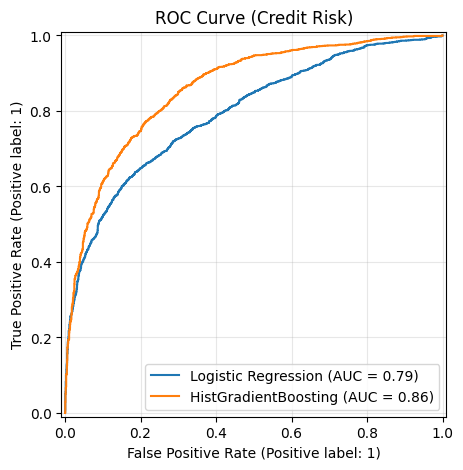

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_estimator(log_reg, X_test, y_test, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_estimator(hgb,     X_test, y_test, name="HistGradientBoosting", ax=ax)

ax.set_title("ROC Curve (Credit Risk)")
ax.grid(True, alpha=0.3)
plt.show()


### Precision-recall Comparison

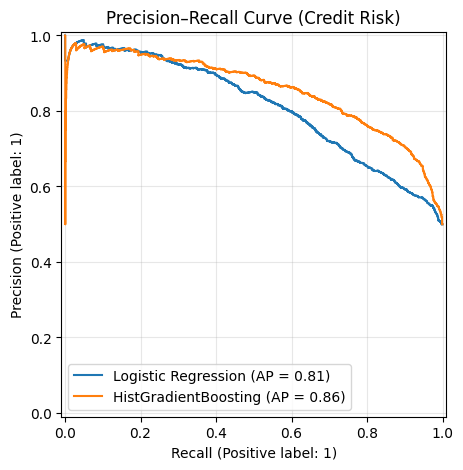

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_estimator(hgb,     X_test, y_test, name="HistGradientBoosting", ax=ax)

ax.set_title("Precision–Recall Curve (Credit Risk)")
ax.grid(True, alpha=0.3)
plt.show()


#### After comparing Logistic Regression and HistGradientBoosting, HGB achieves higher ROC‑AUC and AP, so we select it as the final model.

#### Predictor importance

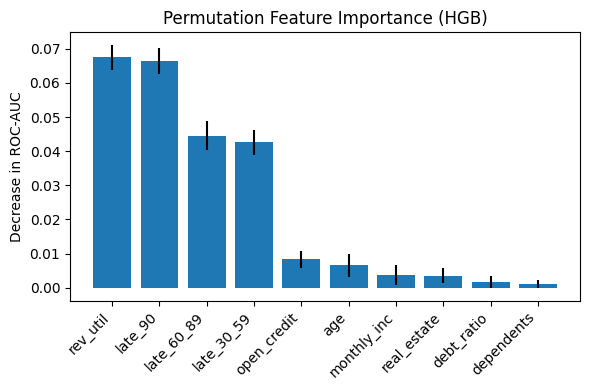

In [10]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

result = permutation_importance(
    hgb, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances_mean = result.importances_mean
importances_std = result.importances_std
feature_names = X_test.columns

idx = np.argsort(importances_mean)[::-1]

plt.figure(figsize=(6, 4))
plt.bar(range(len(idx)), importances_mean[idx],
        yerr=importances_std[idx], align="center")
plt.xticks(range(len(idx)), feature_names[idx], rotation=45, ha="right")
plt.ylabel("Decrease in ROC-AUC")
plt.title("Permutation Feature Importance (HGB)")
plt.tight_layout()
plt.show()


### Correlation between predictors

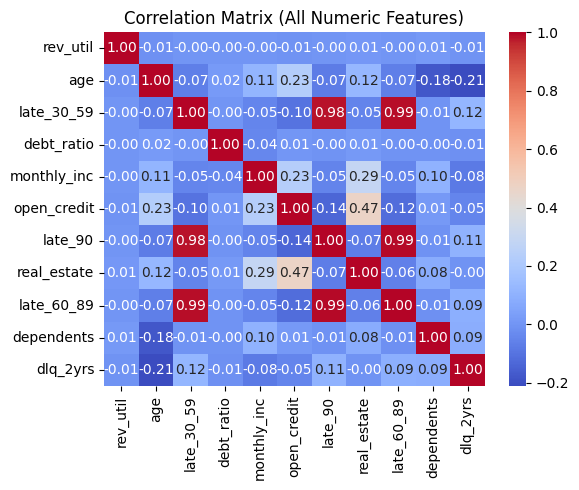

In [11]:
corr = df.corr(numeric_only=True)  # Pearson correlation between numeric columns
corr
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (All Numeric Features)")
plt.tight_layout()
plt.show()


##### Delinquency-count features (late_30_59, late_60_89, late_90) are highly collinear (pairwise correlations ~0.98–0.99), indicating they capture similar underlying repayment-risk behaviour; model importance across these variables should be interpreted as shared signal rather than independent effects.

### Re-training the model using 'late_90' only

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

target = "dlq_2yrs"
drop_cols = ["late_30_59", "late_60_89"]  # keep late_90

X_red = df.drop(columns=[target] + drop_cols)
y = df[target].astype(int)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red, y, test_size=0.2, random_state=42, stratify=y
)

hgb_red = HistGradientBoostingClassifier(random_state=42)
hgb_red.fit(Xr_train, yr_train)

proba_red = hgb_red.predict_proba(Xr_test)[:, 1]
print("Reduced HGB ROC-AUC:", roc_auc_score(yr_test, proba_red))
print("Reduced HGB PR-AUC (AP):", average_precision_score(yr_test, proba_red))


Reduced HGB ROC-AUC: 0.828348924375571
Reduced HGB PR-AUC (AP): 0.8276525534560233


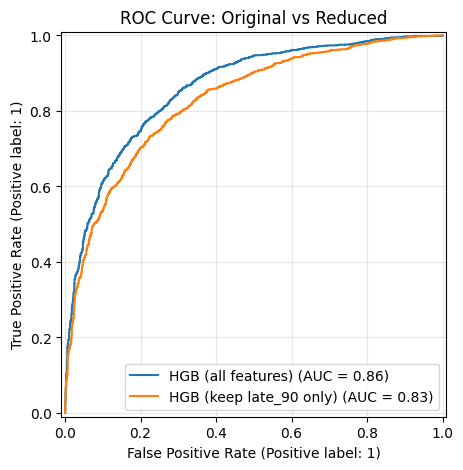

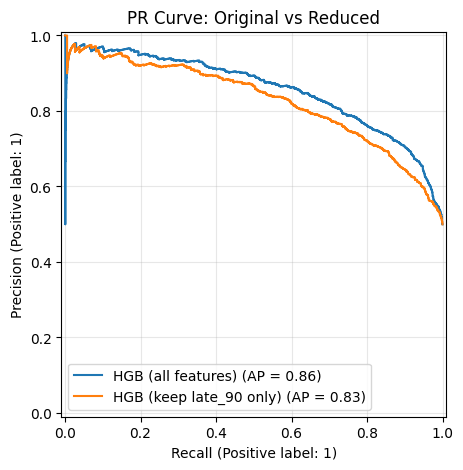

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# ROC
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(hgb,     X_test,  y_test,  name="HGB (all features)", ax=ax)
RocCurveDisplay.from_estimator(hgb_red, Xr_test, yr_test, name="HGB (keep late_90 only)", ax=ax)
ax.set_title("ROC Curve: Original vs Reduced")
ax.grid(True, alpha=0.3)
plt.show()

# Precision–Recall
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_estimator(hgb,     X_test,  y_test,  name="HGB (all features)", ax=ax)
PrecisionRecallDisplay.from_estimator(hgb_red, Xr_test, yr_test, name="HGB (keep late_90 only)", ax=ax)
ax.set_title("PR Curve: Original vs Reduced")
ax.grid(True, alpha=0.3)
plt.show()


#### Performance is robust; delinquency variables are collinear so one (late_90) captures most of the signal.

### Calibration Plot

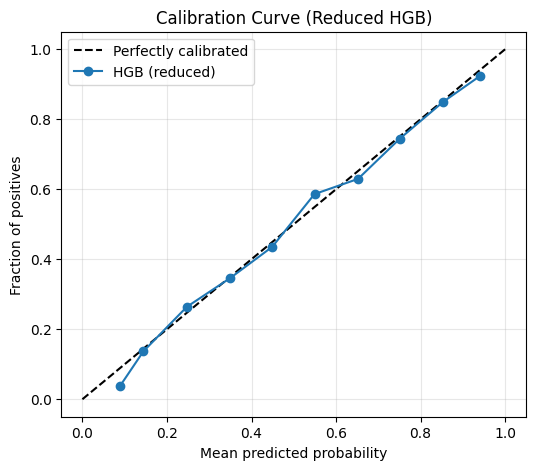

In [14]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

proba = hgb_red.predict_proba(Xr_test)[:, 1]
frac_pos, mean_pred = calibration_curve(yr_test, proba, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.plot(mean_pred, frac_pos, marker="o", label="HGB (reduced)")
plt.title("Calibration Curve (Reduced HGB)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Compute Brier score

In [15]:
from sklearn.metrics import brier_score_loss

proba = hgb_red.predict_proba(Xr_test)[:, 1]
brier = brier_score_loss(yr_test, proba)
print("Brier score loss:", brier)


Brier score loss: 0.1688931458729136


In [16]:
import joblib
from pathlib import Path

bundle = {
    "model": hgb_red,
    "feature_names": list(X_red.columns),
    "target_name": "dlq_2yrs",
}

Path("models").mkdir(exist_ok=True)
joblib.dump(bundle, "models/credit_risk_hgb_bundle.joblib")


['models/credit_risk_hgb_bundle.joblib']